### **SPAM/HAM Email Classifier using SVM Exercise Classical approach Bag-of-words**

This notebook implements a spam email classifier using Support Vector Machines (SVM) with a Bag of Words model.
To compare with the SVM implementation there are some alternative classifiers created.

#### **Table of Contents**
1. [Setup and Imports](#1-setup-and-imports)
2. [Data Loading and Exploration](#2-data-loading-and-exploration)
3. [Feature Engineering](#3-feature-engineering)
4. [Bag of Words Model](#4-bag-of-words-model)
5. [Data Preprocessing](#5-data-preprocessing)
6. [SVM Model Training](#6-svm-model-training)
7. [Model Evaluation](#7-model-evaluation)

#### **Summary**

This notebook implemented a SPAM/HAM email classifier using:

1. **Feature Engineering**: Custom features based on word frequencies, character counts, and text statistics
2. **Bag of Words**: TF-IDF vectorization with unigrams and bigrams
3. **SVM Classifier**: Linear kernel SVM with class weight balancing

The model was evaluated using cross-validation and a held-out validation set before generating predictions on the test set.

#### **Potential Improvements:**
- Experiment with different SVM kernels (RBF, polynomial)
- Try different feature engineering approaches
- Use ensemble methods
- Tune hyperparameters with grid search
- Add more domain-specific features

This version has a naive SVM(), and the final result is 72%.  There is no hyperparameter optimization
  


#### **1. Setup and Imports**

In [36]:
# Standard library imports
import os
import re
import glob
from collections import defaultdict

# Data manipulation
import numpy as np
import pandas as pd

# Machine learning
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful!")

All imports successful!


#### **2. Data Loading and Exploration**

In [37]:
# Define data paths
BASE_DIR = 'data/'
SPAM_DIR = BASE_DIR + 'spam/'
HAM_DIR = BASE_DIR + 'ham/'
TEST_DIR = BASE_DIR + 'test/'

# Count files in each directory
spam_files = glob.glob(SPAM_DIR + '*.txt')
ham_files = glob.glob(HAM_DIR + '*.txt')
test_files = [TEST_DIR + str(x) + '.txt' for x in range(1000)]  # Test files are numbered 0-999

print(f"Number of SPAM emails: {len(spam_files)}")
print(f"Number of HAM emails: {len(ham_files)}")
print(f"Number of TEST emails: {len(test_files)}")
print(f"\nTotal training emails: {len(spam_files) + len(ham_files)}")

Number of SPAM emails: 1200
Number of HAM emails: 2971
Number of TEST emails: 1000

Total training emails: 4171


In [38]:
def read_email(filepath):
    """Read email content from a file."""
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read()
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return ""

In [39]:
# Sample a SPAM email
print("=" * 50)
print("SAMPLE SPAM EMAIL:")
print("=" * 50)
print(read_email(spam_files[0])[:500])

SAMPLE SPAM EMAIL:
Subject: enjoy it
generic viagra , at cheap prices .
most places charge $ 20 , we charge $ 3 . quite a difference , huh ?
an amazing erection within several seconds is
guaranteed to you !
go into sexual overdrive today . . . vroooom !
shipped worldwide . your easy - to - use solution is here : http : / / www . wwwbargins . biz / via / ? oxygen
- - - - -
link below is for that people who dislike
adv . . . . .
http : / / www . wwwbargins . biz / off . html



In [40]:
# Sample a HAM email
print("=" * 50)
print("SAMPLE HAM EMAIL:")
print("=" * 50)
print(read_email(ham_files[0])[:500])

SAMPLE HAM EMAIL:
Subject: hpl nom for january 9 , 2001
( see attached file : hplnol 09 . xls )
- hplnol 09 . xls


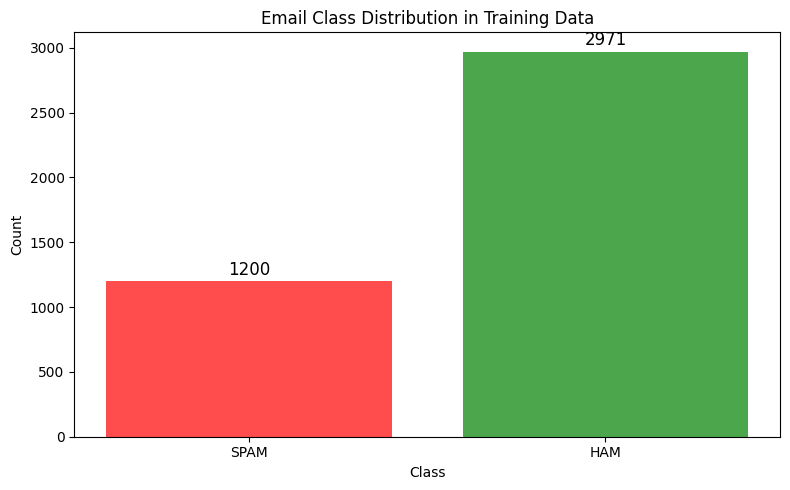

In [41]:
# Visualize class distribution
labels = ['SPAM', 'HAM']
counts = [len(spam_files), len(ham_files)]

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color=['red', 'green'], alpha=0.7)
plt.title('Email Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

#### **3. Feature Engineering**

We will create custom features based on the structure in `featurize.py` plus additional features that may help classify spam vs ham emails.

In [42]:
# ============================================================
# WORD-BASED FEATURES (from featurize.py)
# ============================================================

def freq_word_feature(word):
    """Factory function to create word frequency features."""
    def feature(text, freq):
        return float(freq[word])
    return feature

# Common spam indicator words
SPAM_WORDS = [
    'pain', 'private', 'bank', 'money', 'drug', 'spam', 'prescription',
    'creative', 'height', 'featured', 'differ', 'width', 'other', 'energy',
    'business', 'message', 'volumes', 'revision', 'path', 'meter', 'memo',
    'planning', 'pleased', 'record', 'out', 'free', 'click', 'offer',
    'winner', 'urgent', 'viagra', 'pills', 'casino', 'lottery', 'prize',
    'credit', 'income', 'save', 'discount', 'deal', 'limited', 'act',
    'now', 'cash', 'earn', 'million', 'rich', 'cheap', 'buy', 'order'
]

In [43]:
# ============================================================
# CHARACTER-BASED FEATURES
# ============================================================

def freq_char_feature(char):
    """Factory function to create character count features."""
    def feature(text, freq):
        return text.count(char)
    return feature

# Special characters often found in spam
SPECIAL_CHARS = [';', '$', '#', '!', '(', '[', '&', '@', '%', '*', '?']

In [44]:
# ============================================================
# CUSTOM FEATURES (Additional spam indicators)
# ============================================================

def has_html_tags(text, freq):
    """Check for HTML tags (common in spam)."""
    return int(bool(re.search(r'<[^>]+>', text)))

def count_urls(text, freq):
    """Count number of URLs in the email."""
    return len(re.findall(r'http[s]?://|www\.', text))

def count_uppercase_words(text, freq):
    """Count words in ALL CAPS (common in spam)."""
    words = re.findall(r'\b[A-Z]{2,}\b', text)
    return len(words)

def avg_word_length(text, freq):
    """Calculate average word length."""
    words = re.findall(r'\w+', text)
    if len(words) == 0:
        return 0
    return sum(len(w) for w in words) / len(words)

def count_numbers(text, freq):
    """Count numbers in the email."""
    return len(re.findall(r'\d+', text))

def text_length(text, freq):
    """Total length of the email."""
    return len(text)

def word_count(text, freq):
    """Total number of words."""
    return len(re.findall(r'\w+', text))

def count_lines(text, freq):
    """Count number of lines."""
    return text.count('\n')

def has_subject(text, freq):
    """Check if email has a Subject line."""
    return int('subject:' in text.lower())

def exclamation_ratio(text, freq):
    """Ratio of exclamation marks to text length."""
    if len(text) == 0:
        return 0
    return text.count('!') / len(text) * 100

def uppercase_ratio(text, freq):
    """Ratio of uppercase characters."""
    if len(text) == 0:
        return 0
    upper = sum(1 for c in text if c.isupper())
    return upper / len(text) * 100

def digit_ratio(text, freq):
    """Ratio of digits to text length."""
    if len(text) == 0:
        return 0
    digits = sum(1 for c in text if c.isdigit())
    return digits / len(text) * 100

In [45]:
# ============================================================
# FEATURE VECTOR GENERATION
# ============================================================

def generate_feature_vector(text, freq):
    """Generate a feature vector for a given email."""
    features = []
    
    # Word frequency features
    for word in SPAM_WORDS:
        features.append(float(freq[word]))
    
    # Character frequency features
    for char in SPECIAL_CHARS:
        features.append(text.count(char))
    
    # Custom features
    features.append(has_html_tags(text, freq))
    features.append(count_urls(text, freq))
    features.append(count_uppercase_words(text, freq))
    features.append(avg_word_length(text, freq))
    features.append(count_numbers(text, freq))
    features.append(text_length(text, freq))
    features.append(word_count(text, freq))
    features.append(count_lines(text, freq))
    features.append(has_subject(text, freq))
    features.append(exclamation_ratio(text, freq))
    features.append(uppercase_ratio(text, freq))
    features.append(digit_ratio(text, freq))
    
    return features

# Feature names for reference
FEATURE_NAMES = (
    SPAM_WORDS + 
    [f'char_{c}' for c in SPECIAL_CHARS] +
    ['has_html', 'url_count', 'caps_words', 'avg_word_len', 'number_count',
     'text_length', 'word_count', 'line_count', 'has_subject',
     'exclamation_ratio', 'uppercase_ratio', 'digit_ratio']
)

print(f"Total number of custom features: {len(FEATURE_NAMES)}")

Total number of custom features: 73


In [46]:
def generate_design_matrix(filenames, verbose=True):
    """Generate design matrix from email files."""
    design_matrix = []
    texts = []
    
    for i, filename in enumerate(filenames):
        if verbose and i % 500 == 0:
            print(f"Processing file {i}/{len(filenames)}...")
        
        text = read_email(filename)
        if not text:
            continue
            
        text_clean = text.replace('\r\n', ' ')
        texts.append(text_clean)
        
        # Create word frequency dictionary
        words = re.findall(r'\w+', text_clean.lower())
        word_freq = defaultdict(int)
        for word in words:
            word_freq[word] += 1
        
        # Generate feature vector
        feature_vector = generate_feature_vector(text_clean, word_freq)
        design_matrix.append(feature_vector)
    
    if verbose:
        print(f"Done! Processed {len(design_matrix)} emails.")
    
    return np.array(design_matrix), texts

#### **4. Bag of Words Model**

We will create a Bag of Words representation using scikit-learn's `CountVectorizer`.

In [47]:
# Load all email texts
print("Loading SPAM emails...")
spam_texts = [read_email(f) for f in spam_files]
spam_texts = [t.replace('\r\n', ' ') for t in spam_texts if t]

print("Loading HAM emails...")
ham_texts = [read_email(f) for f in ham_files]
ham_texts = [t.replace('\r\n', ' ') for t in ham_texts if t]

print("Loading TEST emails...")
test_texts = [read_email(f) for f in test_files]
test_texts = [t.replace('\r\n', ' ') for t in test_texts]

# Combine training texts
all_train_texts = spam_texts + ham_texts

print(f"\nTotal training texts: {len(all_train_texts)}")
print(f"Total test texts: {len(test_texts)}")

Loading SPAM emails...
Loading HAM emails...
Loading TEST emails...

Total training texts: 4171
Total test texts: 1000


In [48]:
# Create Bag of Words model using CountVectorizer
print("Creating Bag of Words model...")

# Using TF-IDF which often works better than raw counts
vectorizer = TfidfVectorizer(
    max_features=5000,       # Limit vocabulary size
    min_df=2,                # Ignore terms that appear in fewer than 2 documents
    max_df=0.95,             # Ignore terms that appear in more than 95% of documents
    stop_words='english',    # Remove common English stop words
    ngram_range=(1, 2),      # Use unigrams and bigrams
    lowercase=True
)

# Fit on training data and transform
X_bow_train = vectorizer.fit_transform(all_train_texts)
X_bow_test = vectorizer.transform(test_texts)

print(f"BoW Training matrix shape: {X_bow_train.shape}")
print(f"BoW Test matrix shape: {X_bow_test.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Creating Bag of Words model...
BoW Training matrix shape: (4171, 5000)
BoW Test matrix shape: (1000, 5000)
Vocabulary size: 5000


In [49]:
# Show top words in vocabulary
feature_names = vectorizer.get_feature_names_out()
print("Sample vocabulary words:")
print(feature_names[:20])

Sample vocabulary words:
['00' '00 00' '00 20' '00 25' '00 31' '00 32' '00 463' '00 60' '00 90'
 '00 daren' '00 deal' '00 deliveries' '00 nomination' '00 pm' '00 price'
 '00 production' '000' '000 00' '000 000' '000 day']


#### **5. Data Preprocessing**

Combine custom features with Bag of Words features and prepare the data for training.

In [50]:
# Generate custom features
print("Generating custom features for SPAM emails...")
X_custom_spam, _ = generate_design_matrix(spam_files)

print("\nGenerating custom features for HAM emails...")
X_custom_ham, _ = generate_design_matrix(ham_files)

print("\nGenerating custom features for TEST emails...")
X_custom_test, _ = generate_design_matrix(test_files)

Generating custom features for SPAM emails...
Processing file 0/1200...
Processing file 500/1200...
Processing file 1000/1200...
Done! Processed 1200 emails.

Generating custom features for HAM emails...
Processing file 0/2971...
Processing file 500/2971...
Processing file 1000/2971...
Processing file 1500/2971...
Processing file 2000/2971...
Processing file 2500/2971...
Done! Processed 2971 emails.

Generating custom features for TEST emails...
Processing file 0/1000...
Processing file 500/1000...
Done! Processed 1000 emails.


In [51]:
# Combine custom features
X_custom_train = np.vstack([X_custom_spam, X_custom_ham])

print(f"Custom features training shape: {X_custom_train.shape}")
print(f"Custom features test shape: {X_custom_test.shape}")

Custom features training shape: (4171, 73)
Custom features test shape: (1000, 73)


In [52]:
# Combine BoW features with custom features
from scipy.sparse import hstack, csr_matrix

# Convert custom features to sparse matrix
X_custom_train_sparse = csr_matrix(X_custom_train)
X_custom_test_sparse = csr_matrix(X_custom_test)

# Combine features
X_train_combined = hstack([X_bow_train, X_custom_train_sparse])
X_test_combined = hstack([X_bow_test, X_custom_test_sparse])

print(f"Combined training features shape: {X_train_combined.shape}")
print(f"Combined test features shape: {X_test_combined.shape}")

Combined training features shape: (4171, 5073)
Combined test features shape: (1000, 5073)


In [53]:
# Create labels: 1 for SPAM, 0 for HAM
y_train = np.array([1] * len(spam_texts) + [0] * len(ham_texts))

print(f"Training labels shape: {y_train.shape}")
print(f"Class distribution: SPAM={sum(y_train==1)}, HAM={sum(y_train==0)}")

Training labels shape: (4171,)
Class distribution: SPAM=1200, HAM=2971


In [54]:
# Split training data for validation
X_train, X_val, y_train_split, y_val = train_test_split(
    X_train_combined, y_train, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

Training set size: 3336
Validation set size: 835


#### **6. SVM Model Training**

In [55]:
# Train a basic SVM model
print("Training SVM model...")

svm_model = SVC()

svm_model.fit(X_train, y_train_split)
print("Training complete!")
print(f"Accuracy on Training split: {svm_model.score(X_train, y_train_split):.4f}")

Training SVM model...
Training complete!
Accuracy on Training split: 0.7176


In [56]:
# Cross-validation on the full training set
print("Performing 5-fold cross-validation...")

cv_scores = cross_val_score(
    SVC(),
    X_train_combined, y_train, 
    cv=5, 
    scoring='accuracy'
)

print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Performing 5-fold cross-validation...

Cross-validation scores: [0.71736527 0.71223022 0.71582734 0.71822542 0.71223022]
Mean CV accuracy: 0.7152 (+/- 0.0050)


#### **7. Model Evaluation**

In [57]:
# Evaluate on validation set
y_val_pred = svm_model.predict(X_val)

print("Validation Set Performance:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['HAM', 'SPAM']))

Validation Set Performance:
Accuracy: 0.7150

Classification Report:
              precision    recall  f1-score   support

         HAM       0.72      0.99      0.83       595
        SPAM       0.58      0.03      0.06       240

    accuracy                           0.71       835
   macro avg       0.65      0.51      0.44       835
weighted avg       0.68      0.71      0.61       835



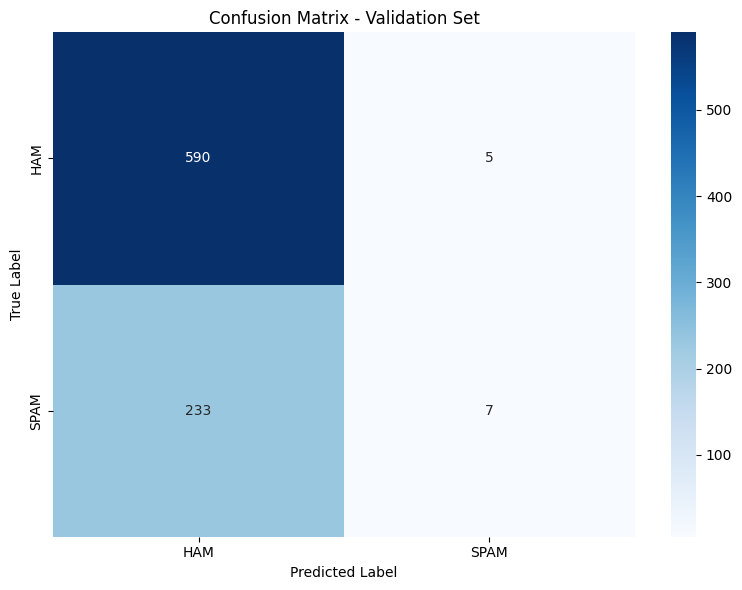

In [58]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['HAM', 'SPAM'],
            yticklabels=['HAM', 'SPAM'])
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [59]:
# Train final model on ALL training data
print("Training final model on all training data...")

final_svm = SVC()

final_svm.fit(X_train_combined, y_train)
print("Final model trained!")

Training final model on all training data...
Final model trained!


#### **8. Test Predictions and Submission**

In [60]:
# Generate predictions on test set
print("Generating predictions on test set...")
y_test_pred = final_svm.predict(X_test_combined)

print(f"Test predictions shape: {y_test_pred.shape}")
print(f"Predicted SPAM: {sum(y_test_pred == 1)}")
print(f"Predicted HAM: {sum(y_test_pred == 0)}")

Generating predictions on test set...
Test predictions shape: (1000,)
Predicted SPAM: 13
Predicted HAM: 987


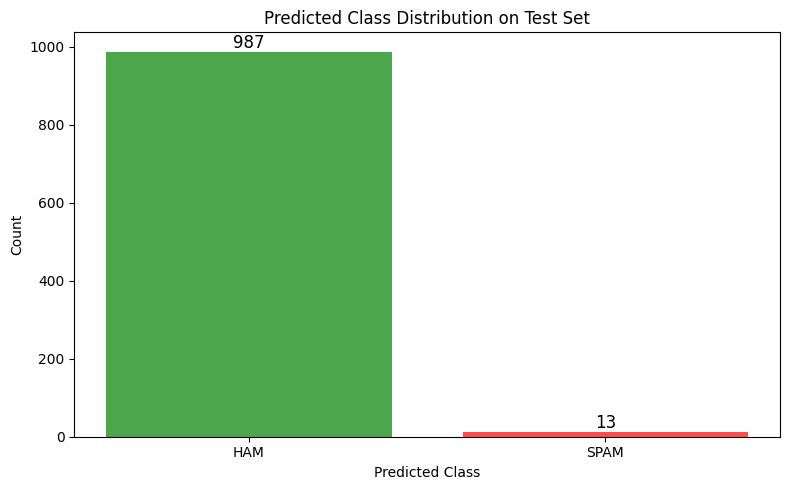

In [61]:
# Visualize test predictions distribution
plt.figure(figsize=(8, 5))
labels = ['HAM', 'SPAM']
counts = [sum(y_test_pred == 0), sum(y_test_pred == 1)]
plt.bar(labels, counts, color=['green', 'red'], alpha=0.7)
plt.title('Predicted Class Distribution on Test Set')
plt.xlabel('Predicted Class')
plt.ylabel('Count')
for i, count in enumerate(counts):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

In [62]:
# Save predictions to CSV using the save_csv snippet
def results_to_csv(y_test, file_name):
    """Save predictions to Kaggle-accepted CSV format."""
    y_test = y_test.astype(int)
    df = pd.DataFrame({'Category': y_test})
    df.index += 1  # Kaggle expects 1-indexed IDs
    df.to_csv(file_name, index_label='Id')
    print(f"Predictions saved to {file_name}")
    return df

In [63]:
# Create submission file
from datetime import datetime

ts = datetime.now().strftime("%Y-%m-%d-%H-%M")
sub_name = 'submission raw data unmodified'+ts+'.csv'
submission_df = results_to_csv(y_test_pred, sub_name)

# Display first few rows
print('Submission file generated as', sub_name)
print("\nSubmission file preview:")
print(submission_df.head(10))

Predictions saved to submission raw data unmodified2026-04-27-14-13.csv
Submission file generated as submission raw data unmodified2026-04-27-14-13.csv

Submission file preview:
    Category
1          0
2          0
3          0
4          0
5          0
6          0
7          0
8          0
9          0
10         0


In [64]:
# Verify the submission file

print("\nSubmission file verification:")
verify_df = pd.read_csv(sub_name)
print(f"Shape: {verify_df.shape}")
print(f"Columns: {verify_df.columns.tolist()}")
print(f"\nValue counts:")
print(verify_df['Category'].value_counts())


Submission file verification:
Shape: (1000, 2)
Columns: ['Id', 'Category']

Value counts:
Category
0    987
1     13
Name: count, dtype: int64


In [73]:
import sys
!{sys.executable} -m pip install optuna


  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached mako-1.3.11-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 26.0 MB/s eta 0:00:00
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.11-py3-none-any.whl (78 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/7 [tqdm]
   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1/7 [Mako]
   ----------- ---------------------------- 2/7 [greenlet]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
import optuna
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from datetime import datetime

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Optuna calls this function once per trial with different param suggestions
    
    # Parameters that apply to all kernels
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
    C = trial.suggest_float('C', 1e-4, 1e4, log=True)          # log scale: covers many orders of magnitude
    tol = trial.suggest_float('tol', 1e-5, 1e-1, log=True)     # stopping tolerance
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])  # handles class imbalance
    shrinking = trial.suggest_categorical('shrinking', [True, False])  # speed optimization heuristic

    params = dict(kernel=kernel, C=C, tol=tol,
                  class_weight=class_weight, shrinking=shrinking,
                  random_state=42, max_iter=2000)

    # gamma controls the reach of each training point — irrelevant for linear kernel
    if kernel in ['rbf', 'poly', 'sigmoid']:
        params['gamma'] = trial.suggest_float('gamma', 1e-5, 1e2, log=True)

    # coef0 shifts the kernel function — only meaningful for poly and sigmoid
    if kernel in ['poly', 'sigmoid']:
        params['coef0'] = trial.suggest_float('coef0', -10.0, 10.0)

    # degree controls curve complexity — only for polynomial kernel
    if kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 6)

    # Train on the split training set, evaluate on held-out validation set
    model = SVC(**params)
    model.fit(X_train, y_train_split)
    return accuracy_score(y_val, model.predict(X_val))  # Optuna maximizes this value


# Create a study (Optuna's search session) and run 200 trials
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

print("Best accuracy:", study.best_value)
print("Best params: ", study.best_params)

# Retrain the best model on ALL training data (not just the split) before predicting test set
best = SVC(**{k: v for k, v in study.best_params.items()}, random_state=42, max_iter=2000)
best.fit(X_train_combined, y_train)

# Final validation check and classification report
y_val_pred_opt = best.predict(X_val)
print("Validation accuracy (best model, full train):", accuracy_score(y_val, y_val_pred_opt))
print(classification_report(y_val, y_val_pred_opt, target_names=['HAM', 'SPAM']))

# Generate and save test predictions for Kaggle submission
y_test_opt = best.predict(X_test_combined)
ts = datetime.now().strftime('%Y_%m_%d_%H_%M')
sub_name_opt = f'submission_raw_optuna_{ts}.csv'
results_to_csv(y_test_opt, sub_name_opt)
print("Saved:", sub_name_opt)


Best trial: 0. Best value: 0.712575:   0%|          | 1/200 [00:03<10:53,  3.28s/it]c:\Users\97254\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Best trial: 0. Best value: 0.712575:   2%|▏         | 4/200 [00:10<09:11,  2.81s/it]c:\Users\97254\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Best trial: 0. Best value: 0.712575:   2%|▎         | 5/200 [00:11<06:30,  2.00s/it]c:\Users\97254\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
B

Best accuracy: 0.8718562874251496
Best params:  {'kernel': 'rbf', 'C': 71.16055698170075, 'tol': 0.0011563841757074658, 'class_weight': None, 'shrinking': False, 'gamma': 0.0007099165549794644}


c:\Users\97254\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Validation accuracy (best model, full train): 0.9868263473053892
              precision    recall  f1-score   support

         HAM       0.99      0.99      0.99       595
        SPAM       0.97      0.98      0.98       240

    accuracy                           0.99       835
   macro avg       0.98      0.99      0.98       835
weighted avg       0.99      0.99      0.99       835

Predictions saved to submission_raw_optuna_2026_04_27_15_39.csv
Saved: submission_raw_optuna_2026_04_27_15_39.csv
